# 01 — Izgradnja mreže i istraživačka analiza podataka

## Uvod

Ovaj notebook pretvara očišćenu tablicu turizma u stvaran graf i provodi istraživačku analizu podataka (EDA) i nad tabličnim podacima i nad nastalom mrežom, prije nego što se u kasnijim notebookovima pokuša "napredna" analiza (centralnost, otkrivanje zajednica itd.).

## Cilj istraživanja

Konstruirati **mrežu sličnosti destinacija**: čvorovi su gradovi/općine, veze povezuju destinacije čiji je *sezonski* turistički profil sličan, te empirijski — brojkama i grafovima — provjeriti da je nastali graf dobro formiran i strukturno smislen prije nego što se na njega oslonimo u ostatku projekta.

## Metodologija

Za svaku općinu napravimo njezin "sezonski profil" — koliko posto noćenja u toj općini padne na svaki mjesec u godini (siječanj, veljača, ..., prosinac). To je njezin "potpis" sezonalnosti.

Dvije općine povezujemo vezom ako imaju sličan sezonski potpis — odnosno ako im se obrazac posjećenosti kroz godinu poklapa (npr. obje imaju vrhunac
ljeti, ili obje imaju ravnomjernu posjećenost cijele godine). Što su sličnije,to je veza između njih "jača".

Problem je što baš svaka općina ima barem malu sličnost sa svakom drugom općinom — kad bismo povezali sve parove, dobili bismo gusti, nepregledni
graf u kojem je sve povezano sa svime i iz kojeg se ništa korisno ne može zaključiti.
Zato graf "prorjeđujemo": za svaku općinu zadržavamo samo njezinih top 8 najsličnijih općina kao stvarne veze, a sve ostale, slabije veze
odbacujemo. Ovo nije proizvoljna odluka — to je standardni, dobro poznat pristup (tzv. k-najbližih-susjeda) koji se koristi kad se grade
mreže sličnosti u analizi mreža.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 20)

from src.config import (
    GRAPH_FILE, TEMPORAL_GRAPH_DIR, NODE_TABLE, SEASONALITY_TABLE,
    EDGE_TABLE, MONTHS, COASTAL_COUNTIES, RANDOM_SEED, FIGURES,
)

from src import preprocessing, network_construction as nc

## Pokretanje faze predobrade

`src.preprocessing` čita sirovi long-format izvoz, normalizira nazive kolona/dijakritike, pretvara noćenja u 12-mjesečne fingerprinte, i gradi tablicu atributa čvorova (županija, oznaka obale, ukupni iznosi).

In [2]:
preprocessing.run()
nodes = pd.read_parquet(NODE_TABLE)
fingerprints = pd.read_parquet(SEASONALITY_TABLE)
print('nodes:', nodes.shape, ' fingerprints:', fingerprints.shape)

INFO:src.preprocessing:Optional origin-country file C:\Users\Karla\Downloads\croatiantourismnetworkanalysisfixed (1)\data\raw\dzs_origin_country_by_county.csv not found; skipping feeder-market attribute. See data/raw/DOWNLOAD_INSTRUCTIONS.md.
INFO:src.preprocessing:Wrote 554 nodes to C:\Users\Karla\Downloads\croatiantourismnetworkanalysisfixed (1)\data\processed\nodes.parquet
INFO:src.preprocessing:Wrote 1108 (region, year) fingerprints to C:\Users\Karla\Downloads\croatiantourismnetworkanalysisfixed (1)\data\processed\seasonality_fingerprints.parquet


nodes: (554, 6)  fingerprints: (1108, 15)


In [3]:
nodes.head()

,region,Arrivals,Nights,Permanent beds,county,coastal
0,Andrijasevci,0.0,0.0,0.0,County of Vukovar-Sirmium,False
1,Antunovac,0.0,0.0,0.0,County of Osijek-Baranja,False
2,Babina Greda,0.0,0.0,0.0,County of Vukovar-Sirmium,False
3,Bakar,5872.0,37135.0,2897.0,County of Primorje Gorski-kotar,True
4,Bale - Valle,62958.0,437124.0,46806.0,County of Istria,True


In [4]:
fingerprints.head()

,region,year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,total_nights
0,Andrijasevci,2019,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Andrijasevci,2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Antunovac,2019,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Antunovac,2020,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Babina Greda,2019,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Međuprovjera: sumiraju li fingerprinti zaista u 1?

Ovo je izravna provjera ispravnosti koraka normalizacije, napravljena ovdje ručno umjesto samo unutar jediničnog testa, jer bi neprimijećena greška ovdje tiho pokvarila svaku kosinusnu sličnost nizvodno.

In [5]:
nonzero = fingerprints[fingerprints['total_nights'] > 0]
row_sums = nonzero[MONTHS].sum(axis=1)
print('min row sum:', row_sums.min(), ' max row sum:', row_sums.max())
assert np.allclose(row_sums, 1.0, atol=1e-6), 'fingerprints do not sum to 1!'
print('OK -- all seasonality fingerprints (with nonzero nights) are valid probability distributions.')
print(f'{(fingerprints["total_nights"] == 0).sum()} region-years have zero nights and an all-zero fingerprint (expected).')

min row sum: 0.9999999999999998  max row sum: 1.0000000000000002
OK -- all seasonality fingerprints (with nonzero nights) are valid probability distributions.
423 region-years have zero nights and an all-zero fingerprint (expected).


## Vizualizacija sirovih krivulja sezonalnosti

Prije izgradnje grafa, pogledajmo izravno nekoliko fingerprinta — to je vektor značajki na kojem je izgrađena cijela mreža, pa ga je vrijedno vidjeti vlastitim očima.

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

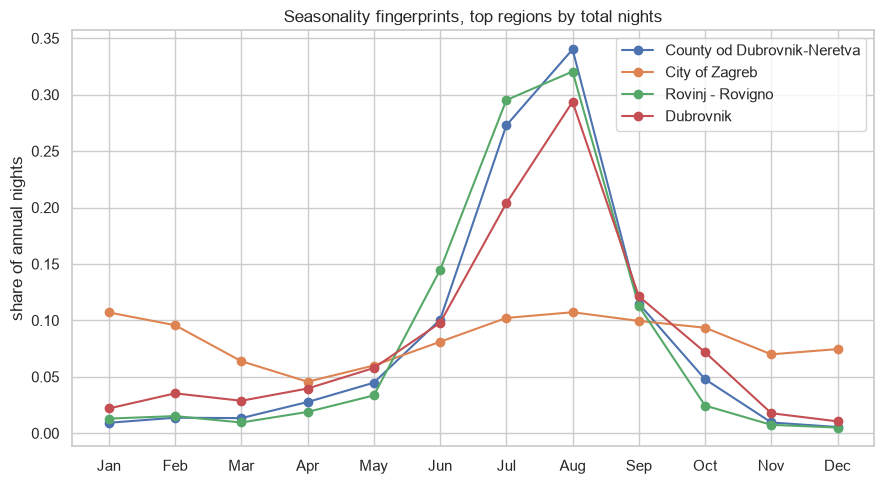

In [6]:
sample_regions = (
    nodes.sort_values('Nights', ascending=False)['region'].head(4).tolist()
    if 'Nights' in nodes.columns else nodes['region'].head(4).tolist()
)
pooled_fp = fingerprints.groupby('region')[MONTHS].mean()

fig, ax = plt.subplots(figsize=(9, 5))
for region in sample_regions:
    ax.plot(MONTHS, pooled_fp.loc[region], marker='o', label=region)
ax.set_title('Seasonality fingerprints, top regions by total nights')
ax.set_ylabel('share of annual nights')
ax.legend()
plt.tight_layout()
plt.show()

## Oblik sezonalnosti: obala vs. kontinent

Središnja modelska pretpostavka cijelog ovog projekta je da obalne i kontinentalne destinacije imaju sustavno različite sezonske oblike. To provjeravamo izravno, usrednjavanjem fingerprinta unutar svake grupe.

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


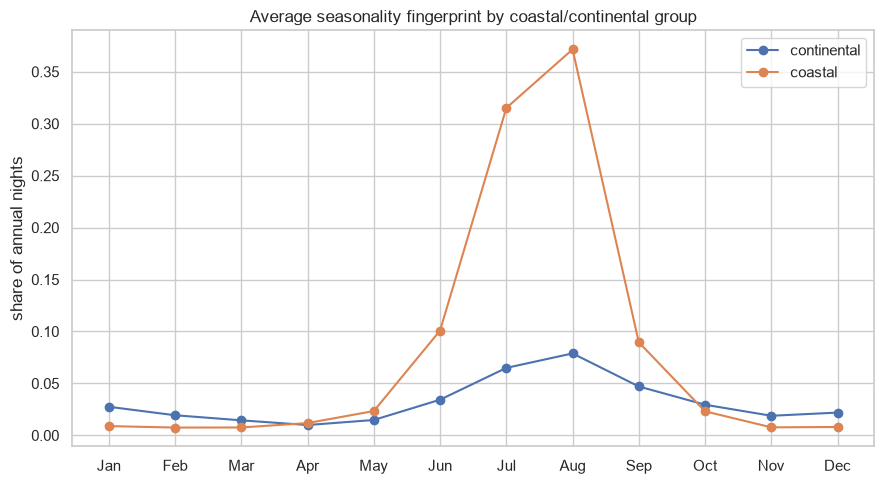

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
coastal,,,,,,,,,,,,
continental,0.027505,0.019340,0.014462,0.009925,0.014796,0.034308,0.064923,0.078859,0.047028,0.029476,0.018843,0.021915
coastal,0.008906,0.007498,0.007572,0.011819,0.023390,0.100871,0.315120,0.371508,0.089556,0.023122,0.007709,0.008043


In [7]:
pooled_with_flag = pooled_fp.merge(nodes[['region', 'coastal']], on='region')
group_mean = pooled_with_flag.groupby('coastal')[MONTHS].mean()
group_mean.index = group_mean.index.map({True: 'coastal', False: 'continental'})

fig, ax = plt.subplots(figsize=(9, 5))
for label, row in group_mean.iterrows():
    ax.plot(MONTHS, row.values, marker='o', label=label)
ax.set_title('Average seasonality fingerprint by coastal/continental group')
ax.set_ylabel('share of annual nights')
ax.legend()
plt.tight_layout()
plt.show()
group_mean

## Izgradnja objedinjenog (višegodišnjeg) grafa sličnosti

`build_pooled_graph` usrednjava fingerprint svake regije kroz sve dostupne godine (ponderirano ukupnim noćenjima te godine) i zatim gradi jedan graf sličnosti iz usrednjenih fingerprinta — ovo je primarni graf koji se koristi u ostatku projekta. Grade se i grafovi po pojedinim godinama, za analizu dinamike mreže u notebooku 05.

In [8]:
g, pooled = nc.build_pooled_graph(fingerprints, nodes)
nc.save_graph(g)
edge_df = nx.to_pandas_edgelist(g)
edge_df.to_parquet(EDGE_TABLE, index=False)

temporal = nc.build_temporal_graphs(fingerprints, nodes)
TEMPORAL_GRAPH_DIR.mkdir(parents=True, exist_ok=True)
for year, tg in temporal.items():
    nc.save_graph(tg, TEMPORAL_GRAPH_DIR / f'graph_{year}.graphml')

print('Pooled graph:', g.number_of_nodes(), 'nodes,', g.number_of_edges(), 'edges')
print('Temporal graphs built for years:', sorted(temporal.keys()))

INFO:src.network_construction:Saved graph (554 nodes, 3691 edges) to C:\Users\Karla\Downloads\croatiantourismnetworkanalysisfixed (1)\data\processed\tourism_network.graphml
INFO:src.network_construction:Saved graph (554 nodes, 3726 edges) to C:\Users\Karla\Downloads\croatiantourismnetworkanalysisfixed (1)\data\processed\temporal_graphs\graph_2019.graphml
INFO:src.network_construction:Saved graph (554 nodes, 3714 edges) to C:\Users\Karla\Downloads\croatiantourismnetworkanalysisfixed (1)\data\processed\temporal_graphs\graph_2020.graphml


Pooled graph: 554 nodes, 3691 edges
Temporal graphs built for years: [2019, 2020]


## Osnovna deskriptivna statistika

Standardne "prve poglede" statistike za bilo koji graf: gustoća, raspon stupnjeva, povezanost, klasteriranje. Ove brojke su temelj za svaku kasniju, sofisticiraniju analizu (npr. krivulje otpornosti imaju smisla samo u odnosu na ovdje prikazanu osnovnu gustoću/povezanost).

In [9]:
n, m = g.number_of_nodes(), g.number_of_edges()
density = nx.density(g)
degrees = [d for _, d in g.degree()]
n_components = nx.number_connected_components(g)
largest_cc = max(len(c) for c in nx.connected_components(g))
avg_clustering = nx.average_clustering(g, weight='weight')

stats = pd.Series({
    'nodes': n,
    'edges': m,
    'density': density,
    'mean_degree': np.mean(degrees),
    'median_degree': np.median(degrees),
    'max_degree': np.max(degrees),
    'min_degree': np.min(degrees),
    'connected_components': n_components,
    'largest_component_fraction': largest_cc / n,
    'avg_clustering_coefficient': avg_clustering,
})
stats.to_frame('value')

,value
nodes,554.000000
edges,3691.000000
density,0.024096
mean_degree,13.324910
median_degree,9.000000
max_degree,215.000000
min_degree,8.000000
connected_components,1.000000
largest_component_fraction,1.000000
avg_clustering_coefficient,0.276975


Gustoća grafa

$$\rho = \frac{2m}{n(n-1)}$$

je, po konstrukciji, niska — top-k prorjeđivanje namjerno zadržava samo najjače veze sličnosti svakog čvora umjesto (puno gušćeg) grafa s pragom, što čuva mrežu čitljivom i izbjegava gotovo potpuno povezan graf koji bi rezultate centralnosti/otkrivanja zajednica učinio besmislenima.

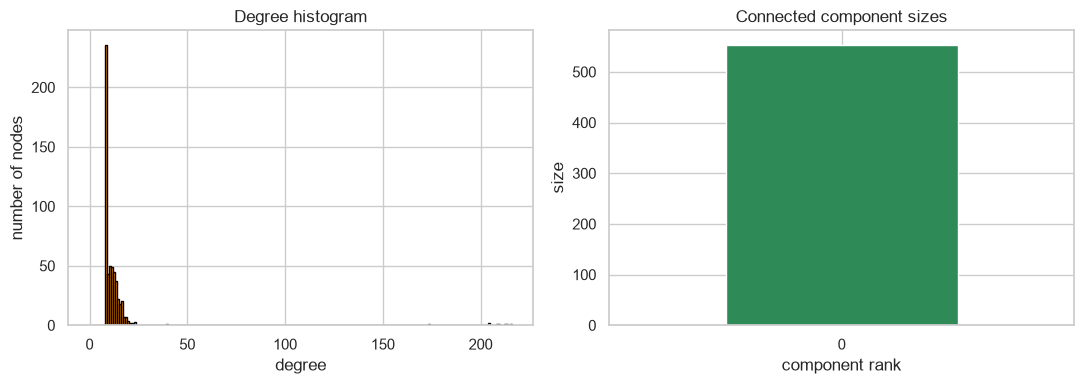

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(degrees, bins=range(0, max(degrees) + 2), color='darkorange', edgecolor='black')
axes[0].set_title('Degree histogram')
axes[0].set_xlabel('degree')
axes[0].set_ylabel('number of nodes')

comp_sizes = sorted((len(c) for c in nx.connected_components(g)), reverse=True)
axes[1].bar(range(len(comp_sizes)), comp_sizes, color='seagreen', width=0.5)
axes[1].set_title('Connected component sizes')
axes[1].set_xlabel('component rank')
axes[1].set_ylabel('size')
axes[1].set_xticks(range(len(comp_sizes)))
axes[1].set_xlim(-0.5, max(len(comp_sizes) - 0.5, 0.5))
plt.tight_layout()
plt.show()

## Vizualizacija mreže

Force-directed (spring) raspored, obojen prema obalnom/kontinentalnom statusu, veličina prema ponderiranom stupnju (ukupna "masa" sličnosti). Ovo je u ovoj fazi čisto istraživačko — formalno rangiranje centralnosti dolazi u notebooku 02, a struktura zajednica u notebooku 03.

In [11]:
edge_weights = nx.get_edge_attributes(g, 'weight')
threshold = sorted(edge_weights.values(), reverse=True)[int(0.08 * len(edge_weights))]
strong_edges = [e for e, w in edge_weights.items() if w >= threshold]

sub_full = g.edge_subgraph(strong_edges).copy()
# Keep only the largest connected piece -- scattered tiny islands across
# the canvas are what made the last plot unreadable.
largest_cc = max(nx.connected_components(sub_full), key=len)
sub = sub_full.subgraph(largest_cc).copy()

sub_deg = dict(sub.degree(weight='weight'))
sub_color_map = {node: color_map[i] for i, node in enumerate(g.nodes()) if node in sub.nodes()}
sizes = [80 + 400 * sub_deg[node] / max(sub_deg.values()) for node in sub.nodes()]
colors = [sub_color_map[node] for node in sub.nodes()]

fig, ax = plt.subplots(figsize=(14, 14))
pos = nx.spring_layout(sub, weight='weight', seed=RANDOM_SEED, k=4.0 / max(1, sub.number_of_nodes()) ** 0.5, iterations=300)
nx.draw_networkx_edges(sub, pos, alpha=0.4, width=0.6, edge_color='gray', ax=ax)
nx.draw_networkx_nodes(sub, pos, node_size=sizes, node_color=colors, ax=ax, linewidths=0)
nx.draw_networkx_labels(sub, pos, font_size=8, ax=ax)

ax.set_title(f'Tourism destination-similarity network (blue=coastal, orange=continental)\nlargest connected component, {sub.number_of_nodes()} nodes, top 8% strongest edges')
ax.set_axis_off()
plt.tight_layout()
plt.show()

NameError: name 'color_map' is not defined

## Interpretacija

Vizualno, obalni čvorovi (plavo) imaju tendenciju grupiranja zajedno, a kontinentalni čvorovi (narančasto) također, što je upravo ono što bi konstrukcija temeljena na sezonskoj sličnosti trebala proizvesti: destinacije s oštrim ljetnim vrhuncem (obalna odmarališta) međusobno su slične, a "ravnije", destinacije orijentirane poslovnom/gradskom turizmu (kontinentalne) međusobno su slične, ali različite od obalne grupe. Ovo kvalitativno opažanje formalno se testira pomoću Normalizirane uzajamne informacije (Normalized Mutual Information) naspram obalne/kontinentalne oznake u notebooku 03 (Otkrivanje zajednica).

## Zaključak

Objedinjeni graf sličnosti i njegovi godišnji parnjaci su izgrađeni, spremljeni u `data/processed/`, i prolaze osnovne provjere ispravnosti (valjani fingerprinti, plauzibilna gustoća, vizualno koherentno razdvajanje obale/kontinenta). Notebookovi 02 nadalje grade na `tourism_network.graphml` spremljenom ovdje.